In [100]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
)
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression


**Data Extraction**

In [101]:
data = r'D:\Phone addicted\Smartphone-Addiction-Warning-System-Rebuild-\data\Preprocessed Data\preprocessed_data.csv'
df = pd.read_csv(data)
df

,Age,Gender,Daily_Usage_Hours,Addiction_Level,Tracked_Hours,Untracked_Hours,Leisure_Hours,Leisure_Ratio,Education_Ratio,Social_vs_Gaming,...,Offline_Activity,Online_To_Offline_Ratio,Family_To_Screen_Ratio,Anxiety_Level_z,Depression_Level_z,Self_Esteem_z,Distress_Index,Academic_Per_Usage,Unsupervised_Usage,Grade_Num
0,13,0,4.0,10.0,6.500000,-2.500000,5.300000,1.325000,0.300000,1.900000,...,5.100000,0.784314,1.000000,1.525594,-0.856794,0.857699,-0.523299,19.500000,1.970667,9
1,17,0,5.5,10.0,6.900000,-1.400000,5.100000,0.927273,0.327273,-2.900000,...,6.040667,0.910496,0.363636,-0.895984,0.536178,-0.890092,0.710189,12.727273,2.709667,7
2,13,2,5.8,9.2,2.200000,3.600000,1.800000,0.310345,0.068966,-1.200000,...,8.800000,0.659091,1.034483,-1.241923,-0.856794,1.556816,-2.606174,16.034483,2.857467,11
3,18,0,3.1,9.8,5.500000,-2.400000,4.700000,1.516129,0.258065,1.500000,...,9.600000,0.322917,2.580645,1.179654,1.580908,-0.890092,2.270372,25.161290,1.527267,12
4,14,2,2.5,8.6,4.600000,-2.100000,3.500000,1.400000,0.440000,1.700000,...,5.100000,0.490196,4.000000,-1.587863,-0.160308,-1.589208,0.715123,22.400000,1.231667,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,16,0,3.9,9.8,5.500000,-1.600000,4.500000,1.153846,0.256410,0.900000,...,4.900000,0.795918,2.051282,0.487775,1.580908,-1.239650,2.273991,13.589744,0.000000,12
2996,13,0,3.6,5.5,4.925267,-1.325267,4.625267,1.284796,0.083333,1.574733,...,6.040667,0.595961,2.500000,0.833714,0.884421,1.207257,-0.348189,25.833333,0.000000,8
2997,14,2,3.2,6.2,5.000000,-1.800000,2.600000,0.812500,0.750000,2.200000,...,2.040667,1.568115,2.812500,-0.550044,-0.856794,1.207257,-1.910676,30.625000,1.576533,7
2998,17,0,6.7,10.0,5.800000,0.900000,4.300000,0.641791,0.223881,-0.900000,...,3.200000,2.093750,0.597015,-0.895984,-0.160308,1.207257,-1.735403,10.000000,3.300867,9


In [102]:
df.shape

(3000, 28)

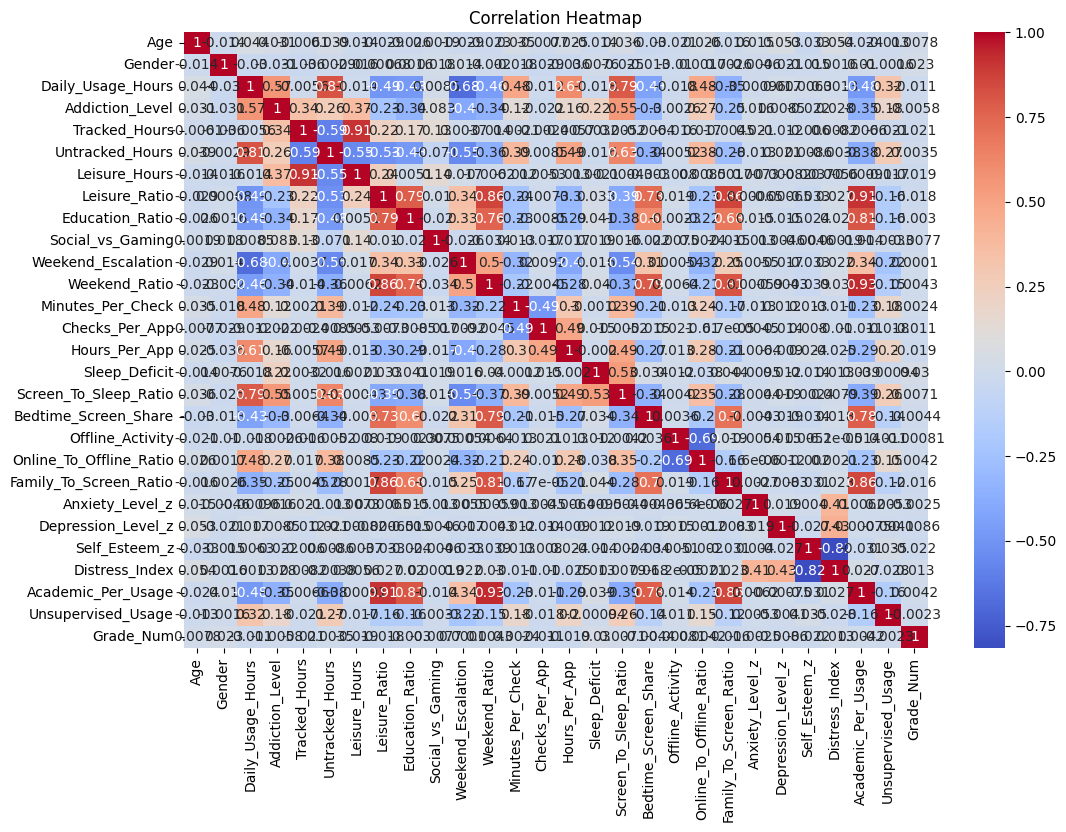

In [103]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Feature Selection**

In [104]:
df.columns

Index(['Age', 'Gender', 'Daily_Usage_Hours', 'Addiction_Level',
       'Tracked_Hours', 'Untracked_Hours', 'Leisure_Hours', 'Leisure_Ratio',
       'Education_Ratio', 'Social_vs_Gaming', 'Weekend_Escalation',
       'Weekend_Ratio', 'Minutes_Per_Check', 'Checks_Per_App', 'Hours_Per_App',
       'Sleep_Deficit', 'Screen_To_Sleep_Ratio', 'Bedtime_Screen_Share',
       'Offline_Activity', 'Online_To_Offline_Ratio', 'Family_To_Screen_Ratio',
       'Anxiety_Level_z', 'Depression_Level_z', 'Self_Esteem_z',
       'Distress_Index', 'Academic_Per_Usage', 'Unsupervised_Usage',
       'Grade_Num'],
      dtype='object')

In [105]:
X = df.drop('Addiction_Level', axis=1)
Y = df['Addiction_Level']
selector = SelectKBest(f_regression, k=18).set_output(transform='pandas')
X_new = selector.fit_transform(X, Y)
X_new.columns

Index(['Daily_Usage_Hours', 'Tracked_Hours', 'Untracked_Hours',
       'Leisure_Hours', 'Leisure_Ratio', 'Education_Ratio', 'Social_vs_Gaming',
       'Weekend_Escalation', 'Weekend_Ratio', 'Minutes_Per_Check',
       'Hours_Per_App', 'Sleep_Deficit', 'Screen_To_Sleep_Ratio',
       'Bedtime_Screen_Share', 'Online_To_Offline_Ratio',
       'Family_To_Screen_Ratio', 'Academic_Per_Usage', 'Unsupervised_Usage'],
      dtype='object')

In [106]:
S = StandardScaler()
X_scaled = S.fit_transform(X_new)
print(X_scaled)

[[-0.55884128  0.90147131 -0.98052299 ... -0.16232732  0.01172471
   0.52651092]
 [ 0.23010699  1.18930865 -0.51466737 ... -0.40385633 -0.26621013
   1.0516203 ]
 [ 0.38789664 -2.19278009  1.60285816 ... -0.14923954 -0.13049096
   1.15664217]
 ...
 [-0.97961368 -0.17791871 -0.68406941 ...  0.52559907  0.46826533
   0.24645258]
 [ 0.8612656   0.39775597  0.45939437 ... -0.31527853 -0.3781302
   1.4717078 ]
 [-0.82182403 -0.25042973 -0.51434268 ...  0.21721827  0.13776803
  -0.87378076]]


In [107]:
X_new_train, X_new_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)
X_new_train.shape, X_new_test.shape, Y_train.shape, Y_test.shape

((2400, 18), (600, 18), (2400,), (600,))

**Single Model**

In [108]:
from sklearn.linear_model import LinearRegression , Ridge , Lasso
from sklearn.metrics import mean_squared_error, r2_score
models = {
    'lr' : LinearRegression(),
    'rid' : Ridge(),
    'las' : Lasso()
}
for model in models:
    models[model].fit(X_new_train, Y_train)
    y_pred = models[model].predict(X_new_test)
    print(f"{model} : ")
    print(f"Mean Squared Error: {mean_squared_error(Y_test, y_pred)}")
    print(f"R2 Score: {r2_score(Y_test, y_pred):.2f}")


lr : 
Mean Squared Error: 0.9645394014470772
R2 Score: 0.62
rid : 
Mean Squared Error: 0.9638310465556663
R2 Score: 0.62
las : 
Mean Squared Error: 2.5193170572916666
R2 Score: -0.00


In [109]:
# from sklearn.model_selection import GridSearchCV
# # NOTE: copy_X is deliberately not searched. It is a memory-management flag, not a
# # hyperparameter - it cannot change model quality. Worse, GridSearchCV refits the
# # winning estimator in this process, so a copy_X=False winner centres X_new_train
# # in place while X_new_test is left alone. Every cell below then trains on shifted
# # data and is scored against unshifted data (gb MSE 0.280 -> 0.414).
# lr_params = {
#     'fit_intercept': [True, False],
#     'positive': [True, False]
#     }
# rid_params = {
#     'alpha': [0.1, 1.0, 10.0],
#     'fit_intercept': [True, False],
#     'max_iter': [None, 1000, 5000],
#     'tol': [1e-4, 1e-3, 1e-2],
#     'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
#     'positive': [True, False]}
# las_params = {
#     'alpha': [0.1, 1.0, 10.0],
#     'fit_intercept': [True, False],
#     'max_iter': [None, 1000, 5000],
#     'tol': [1e-4, 1e-3, 1e-2],
#     'selection': ['cyclic', 'random'],
#     'positive': [True, False]
# }
# single_models_hyperparams_search = {
#     'lr' : lr_params,
#     'rid' : rid_params,
#     'las' : las_params}
# for j in single_models_hyperparams_search:
#     grid_search = GridSearchCV(models[j], single_models_hyperparams_search[j], cv=5, scoring='r2', n_jobs=-1)
#     grid_search.fit(X_new_train, Y_train)
#     print(f"{j} : ")
#     print(f"Best Parameters: {grid_search.best_params_}")
#     print(f"Best R2 Score: {grid_search.best_score_:.2f}")

**Ensemble Learning**


In [110]:
# from sklearn.model_selection import GridSearchCV
# rf_params = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [None, 10, 20],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'bootstrap': [True, False]}
# gb_params = {
#     'n_estimators': [100, 200, 300],
#     'learning_rate': [0.01, 0.1, 0.2],
#     'max_depth': [3, 5, 7],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],}
# xgb_params = {
#     'n_estimators': [100, 200, 300],
#     'learning_rate': [0.01, 0.1, 0.2],
#     'max_depth': [3, 5, 7],
#     'subsample': [0.8, 1.0],
#     'colsample_bytree': [0.8, 1.0],}
# hyperparameter_grids = {
#     'rf': rf_params,
#     'gb': gb_params,
#     'xgb': xgb_params}
# for i in hyperparameter_grids:
#     grid_search = GridSearchCV(estimator=ensemble_models[i], param_grid=hyperparameter_grids[i], cv=5, n_jobs=-1, verbose=2)
#     grid_search.fit(X_new_train, Y_train)
#     print(f"Best parameters for {i}: {grid_search.best_params_}")
#     best_model = grid_search.best_estimator_
#     y_pred = best_model.predict(X_new_test)
#     print(f"{i} : ")
#     print(f"Mean Squared Error: {mean_squared_error(Y_test, y_pred)}")
#     print(f"R2 Score: {r2_score(Y_test, y_pred):.2f}")

In [111]:
from sklearn.ensemble import RandomForestRegressor , GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
ensemble_models = {
    'rf' : RandomForestRegressor(bootstrap=True, max_depth=20, min_samples_leaf=2, min_samples_split=2, n_estimators=100, random_state=42),
    'gb' : GradientBoostingRegressor(learning_rate=0.2, max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=300, random_state=42),
    'xgb' : XGBRegressor(colsample_bytree=0.8, learning_rate=0.2, max_depth=3, n_estimators=300, subsample=1.0, random_state=42)
}
for m in ensemble_models:
    ensemble_models[m].fit(X_new_train, Y_train)
    y_pred = ensemble_models[m].predict(X_new_test)
    print(f"{m} : ")
    print(f"Mean Squared Error: {mean_squared_error(Y_test, y_pred)}")
    print(f"R2 Score: {r2_score(Y_test, y_pred):.2f}")

rf : 
Mean Squared Error: 0.5111102934161212
R2 Score: 0.80
gb : 
Mean Squared Error: 0.27979100352551695
R2 Score: 0.89
xgb : 
Mean Squared Error: 0.2578387686773065
R2 Score: 0.90


**Evaluation**


In [119]:
import numpy as np, pandas as pd, scipy.stats as st
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
    median_absolute_error, mean_absolute_percentage_error,
    r2_score, explained_variance_score)

# X_scaled is a numpy array (no set_output on the scaler), so X_new_train has
# no .columns. The 18 names survive on X_new from Cell 7.
FEATURES = list(X_new.columns)
assert len(FEATURES) == X_new_train.shape[1]

def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b))**2)))

print(f"{len(FEATURES)} features | train {X_new_train.shape} | test {X_new_test.shape}")

18 features | train (2400, 18) | test (600, 18)


In [120]:
from sklearn.linear_model import LinearRegression

lin = LinearRegression().fit(X_new_train, Y_train)
r2_lin = r2_score(Y_test, lin.predict(X_new_test))
best_ens = max(r2_score(Y_test, m.predict(X_new_test)) for m in ensemble_models.values())
print(f"Linear R2 {r2_lin:.4f} | best ensemble R2 {best_ens:.4f}")
print("Deterministic leakage:", "SUSPECTED" if r2_lin > 0.97 else "ruled out")

coefs = pd.Series(lin.coef_, index=FEATURES).sort_values(key=abs, ascending=False)
display(coefs.round(4).to_frame('coef'))

Linear R2 0.6171 | best ensemble R2 0.8977
Deterministic leakage: ruled out


,coef
Daily_Usage_Hours,1.2607
Sleep_Deficit,0.7113
Untracked_Hours,0.6538
Tracked_Hours,0.6139
Screen_To_Sleep_Ratio,-0.6125
Leisure_Ratio,0.5892
Hours_Per_App,-0.4816
Academic_Per_Usage,-0.3258
Minutes_Per_Check,-0.3257
Leisure_Hours,0.2460


In [122]:
def metric_row(y_true, y_pred, name):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    r = y_true - y_pred
    return {'model': name,
            'MSE': mean_squared_error(y_true, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
            'MAE': mean_absolute_error(y_true, y_pred),
            'MedAE': median_absolute_error(y_true, y_pred),
            'R2': f"{r2_score(y_true, y_pred):.2f}",
            'ExplVar': explained_variance_score(y_true, y_pred),
            'MAPE': mean_absolute_percentage_error(y_true, y_pred),
            'bias': r.mean(),
            'p90_abs': np.percentile(np.abs(r), 90),
            'max_abs': np.abs(r).max()}

rows  = [metric_row(Y_test, np.full(len(Y_test), Y_train.mean()), 'baseline_mean')]
rows += [metric_row(Y_test, m.predict(X_new_test), k) for k, m in models.items()]
rows += [metric_row(Y_test, m.predict(X_new_test), k) for k, m in ensemble_models.items()]
display(pd.DataFrame(rows).set_index('model').round(4))

,MSE,RMSE,MAE,MedAE,R2,ExplVar,MAPE,bias,p90_abs,max_abs
model,,,,,,,,,,
baseline_mean,2.5193,1.5872,1.2762,1.1177,-0.00,-0.0000,0.1800,-0.0020,2.3823,6.4823
lr,0.9645,0.9821,0.7448,0.5938,0.62,0.6184,0.0993,-0.0552,1.4549,3.9448
rid,0.9638,0.9817,0.7447,0.5962,0.62,0.6186,0.0993,-0.0550,1.4508,3.9444
las,2.5193,1.5872,1.2762,1.1177,-0.00,-0.0000,0.1800,-0.0020,2.3823,6.4823
rf,0.5111,0.7149,0.4302,0.2282,0.80,0.7976,0.0621,-0.0330,1.0721,4.2174
gb,0.2798,0.5290,0.3589,0.2318,0.89,0.8895,0.0484,-0.0387,0.8210,2.5347
xgb,0.2578,0.5078,0.3319,0.2031,0.90,0.8980,0.0444,-0.0309,0.7822,2.3189


In [ ]:
from sklearn.model_selection import cross_val_score, cross_validate, KFold
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.base import clone
import numpy as np, pandas as pd

cv = KFold(n_splits=5, shuffle=True, random_state=42)
baseline = rmse(Y_test, np.full(len(Y_test), Y_train.mean()))

# ---- report: per-model train vs validation ------------------------------
rows = []
for name, model in ensemble_models.items():
    r = cross_validate(model, X_new_train, Y_train, cv=cv,
                       scoring='neg_root_mean_squared_error',
                       return_train_score=True, n_jobs=-1)
    rows.append({'model': name,
                 'cv_train_RMSE': -r['train_score'].mean(),
                 'cv_val_RMSE':   -r['test_score'].mean(),
                 'cv_std':         r['test_score'].std()})
report = pd.DataFrame(rows).set_index('model')

# ---- sweep: does a simpler model score better? --------------------------
def cv_rmse(model):
    s = -cross_val_score(model, X_new_train, Y_train, cv=cv,
                         scoring='neg_root_mean_squared_error', n_jobs=-1)
    return s.mean(), s.std()

variants = {
    'rf': {
        'current (depth=20, leaf=2)': ensemble_models['rf'],
        'depth=10, leaf=5':  RandomForestRegressor(max_depth=10, min_samples_leaf=5,  n_estimators=100, random_state=42),
        'depth=6, leaf=10':  RandomForestRegressor(max_depth=6,  min_samples_leaf=10, n_estimators=100, random_state=42),
    },
    'gb': {
        'current (lr=0.2, n=300)': ensemble_models['gb'],
        'lr=0.05, n=300':   GradientBoostingRegressor(learning_rate=0.05, n_estimators=300, max_depth=3, random_state=42),
        'lr=0.05, n=150':   GradientBoostingRegressor(learning_rate=0.05, n_estimators=150, max_depth=3, random_state=42),
        'lr=0.05, leaf=10': GradientBoostingRegressor(learning_rate=0.05, n_estimators=300, max_depth=3, min_samples_leaf=10, random_state=42),
    },
    'xgb': {
        'current (lr=0.2, n=300)': ensemble_models['xgb'],
        'lr=0.05, n=300':   XGBRegressor(learning_rate=0.05, n_estimators=300, max_depth=3, random_state=42),
        'lr=0.05, n=150':   XGBRegressor(learning_rate=0.05, n_estimators=150, max_depth=3, random_state=42),
        'lr=0.05, leaf=10': XGBRegressor(learning_rate=0.05, n_estimators=300, max_depth=3, min_child_weight=10, random_state=42),
}
}
rows = []
for family, opts in variants.items():
    for label, mdl in opts.items():
        mean, std = cv_rmse(clone(mdl))
        rows.append({'family': family, 'config': label,
                     'cv_val_RMSE': mean, 'cv_std': std})

sweep = pd.DataFrame(rows)
sweep['vs_current'] = sweep.groupby('family')['cv_val_RMSE'].transform(lambda g: g - g.iloc[0])

print(report.round(4).to_string())
print()
print(sweep.round(4).to_string(index=False))
print("\nvs_current < 0 -> simpler model wins, you were overfitting")
print("vs_current > 0 -> current capacity is earning its keep")

       cv_train_RMSE  cv_val_RMSE  cv_std
model                                    
rf            0.3238       0.7032  0.0534
gb            0.1636       0.5315  0.0301
xgb           0.1808       0.5195  0.0195

family                     config  cv_val_RMSE  cv_std  vs_current
    rf current (depth=20, leaf=2)       0.7032  0.0534      0.0000
    rf           depth=10, leaf=5       0.7239  0.0548      0.0207
    rf           depth=6, leaf=10       0.7952  0.0575      0.0920
    gb    current (lr=0.2, n=300)       0.5315  0.0301      0.0000
    gb             lr=0.05, n=300       0.5797  0.0277      0.0482
    gb             lr=0.05, n=150       0.6430  0.0315      0.1115
    gb           lr=0.05, leaf=10       0.5755  0.0290      0.0440

vs_current < 0 -> simpler model wins, you were overfitting
vs_current > 0 -> current capacity is earning its keep


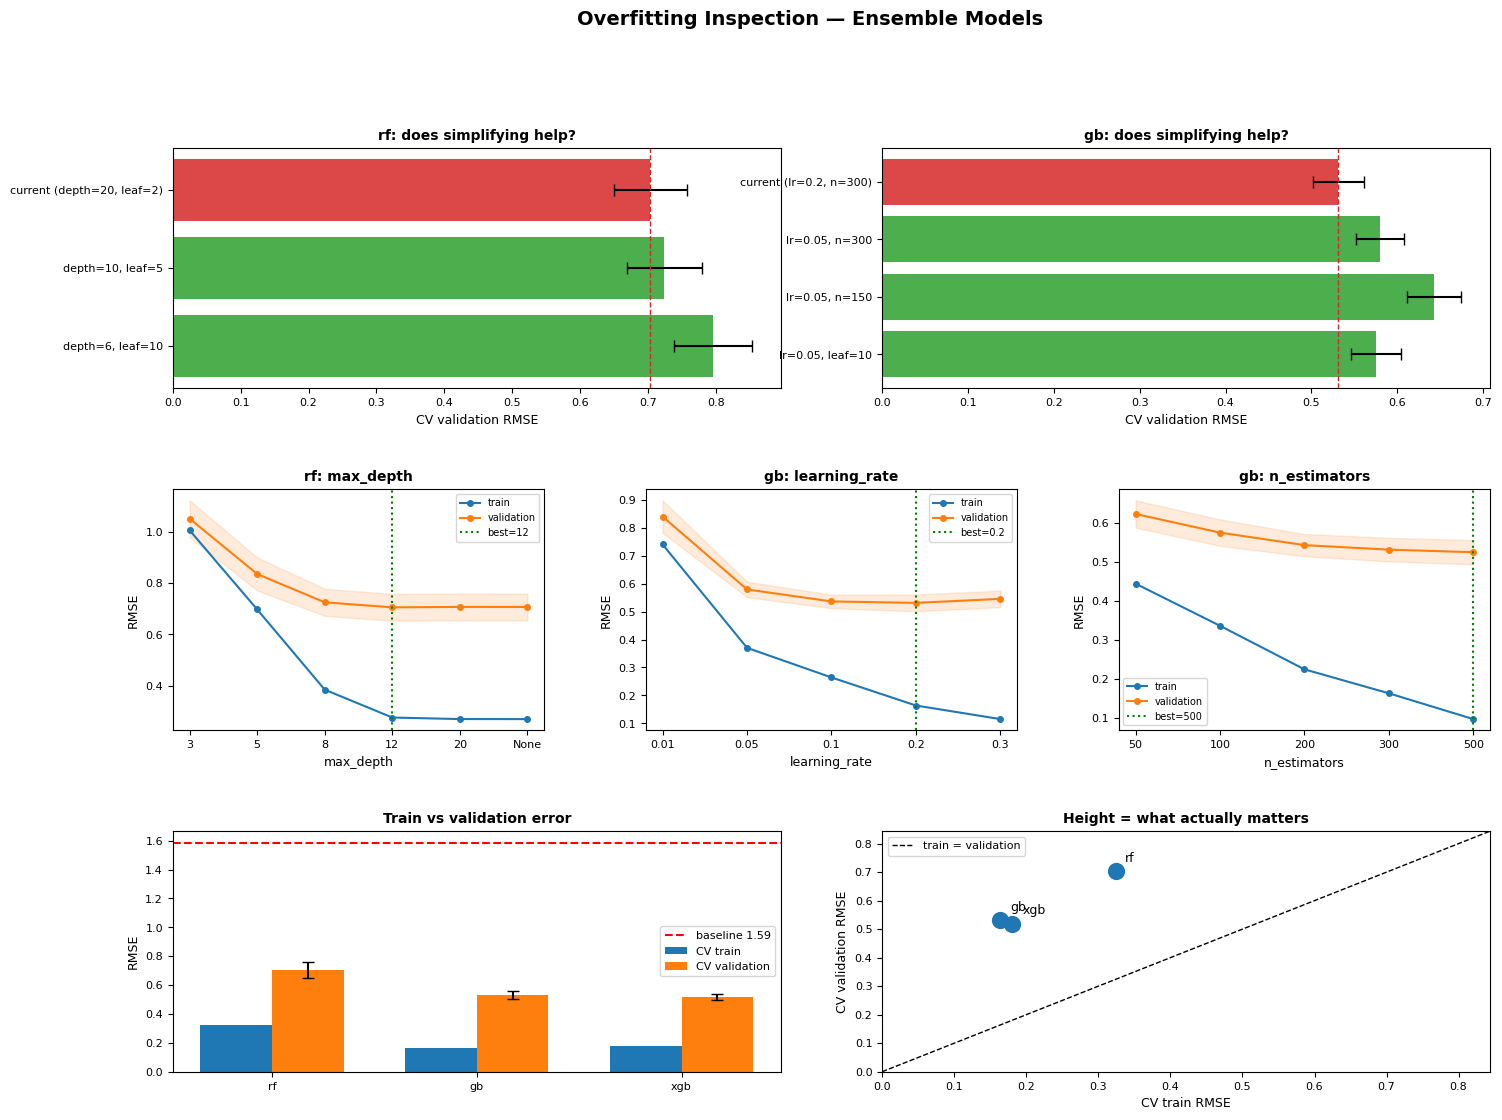

In [132]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.model_selection import validation_curve
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

fig = plt.figure(figsize=(17, 12))
gs = gridspec.GridSpec(3, 6, figure=fig, hspace=0.42, wspace=0.75)

# ── Row 1: capacity sweep ────────────────────────────────────────────────
fams = sweep['family'].unique()
span = 6 // len(fams)
for i, fam in enumerate(fams):
    a = fig.add_subplot(gs[0, i*span:(i+1)*span])
    sub = sweep[sweep['family'] == fam]
    y = np.arange(len(sub))
    a.barh(y, sub['cv_val_RMSE'], xerr=sub['cv_std'], capsize=4, alpha=.85,
           color=['#d62728' if j == 0 else '#2ca02c' for j in range(len(sub))])
    a.axvline(sub['cv_val_RMSE'].iloc[0], color='#d62728', ls='--', lw=1)
    a.set_yticks(y); a.set_yticklabels(sub['config'], fontsize=8)
    a.set_xlabel('CV validation RMSE', fontsize=9)
    a.set_title(f'{fam}: does simplifying help?', fontsize=10, weight='bold')
    a.invert_yaxis(); a.tick_params(labelsize=8)

# ── Row 2: validation curves ─────────────────────────────────────────────
specs = [
    ('rf: max_depth', RandomForestRegressor(n_estimators=100, random_state=42),
     'max_depth', [3, 5, 8, 12, 20, None]),
    ('gb: learning_rate', GradientBoostingRegressor(n_estimators=300, max_depth=3, random_state=42),
     'learning_rate', [0.01, 0.05, 0.1, 0.2, 0.3]),
    ('gb: n_estimators', GradientBoostingRegressor(learning_rate=0.2, max_depth=3, random_state=42),
     'n_estimators', [50, 100, 200, 300, 500]),
]
for i, (title, est, param, rng) in enumerate(specs):
    a = fig.add_subplot(gs[1, i*2:(i+1)*2])
    xs = [str(v) for v in rng]
    tr, va = validation_curve(est, X_new_train, Y_train, param_name=param,
                              param_range=rng, cv=cv, n_jobs=-1,
                              scoring='neg_root_mean_squared_error')
    tr, va = -tr, -va
    a.plot(xs, tr.mean(1), 'o-', color='#1f77b4', ms=4, label='train')
    a.plot(xs, va.mean(1), 'o-', color='#ff7f0e', ms=4, label='validation')
    a.fill_between(xs, va.mean(1)-va.std(1), va.mean(1)+va.std(1),
                   color='#ff7f0e', alpha=.15)
    best = xs[int(np.argmin(va.mean(1)))]
    a.axvline(best, color='green', ls=':', lw=1.5, label=f'best={best}')
    a.set_title(title, fontsize=10, weight='bold')
    a.set_xlabel(param, fontsize=9); a.set_ylabel('RMSE', fontsize=9)
    a.legend(fontsize=7); a.tick_params(labelsize=8)

# ── Row 3: gap in context ────────────────────────────────────────────────
a = fig.add_subplot(gs[2, 0:3])
names = list(report.index); x = np.arange(len(names)); w = .35
a.bar(x - w/2, report['cv_train_RMSE'], w, label='CV train', color='#1f77b4')
a.bar(x + w/2, report['cv_val_RMSE'], w, yerr=report['cv_std'],
      label='CV validation', color='#ff7f0e', capsize=4)
a.axhline(baseline, color='red', ls='--', lw=1.5, label=f'baseline {baseline:.2f}')
a.set_xticks(x); a.set_xticklabels(names)
a.set_ylabel('RMSE', fontsize=9)
a.set_title('Train vs validation error', fontsize=10, weight='bold')
a.legend(fontsize=8); a.tick_params(labelsize=8)

a = fig.add_subplot(gs[2, 3:6])
a.scatter(report['cv_train_RMSE'], report['cv_val_RMSE'], s=130, zorder=3)
for n, r in report.iterrows():
    a.annotate(n, (r['cv_train_RMSE'], r['cv_val_RMSE']),
               xytext=(7, 7), textcoords='offset points', fontsize=9)
lim = [0, report['cv_val_RMSE'].max() * 1.2]
a.plot(lim, lim, 'k--', lw=1, label='train = validation')
a.set_xlim(lim); a.set_ylim(lim)
a.set_xlabel('CV train RMSE', fontsize=9); a.set_ylabel('CV validation RMSE', fontsize=9)
a.set_title('Height = what actually matters', fontsize=10, weight='bold')
a.legend(fontsize=8); a.tick_params(labelsize=8)

fig.suptitle('Overfitting Inspection — Ensemble Models', fontsize=14, weight='bold', y=0.995)
plt.show()

# fig.savefig('overfit_inspection.png', dpi=200, bbox_inches='tight')

In [133]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.base import clone

rows = []
for k, m in ensemble_models.items():
    pipe = Pipeline([('select', SelectKBest(f_regression, k=18)),
                     ('scale', StandardScaler()),
                     ('model', clone(m))])
    s = -cross_val_score(pipe, X, Y, cv=cv,
                         scoring='neg_root_mean_squared_error', n_jobs=-1)
    rows.append({'model': k, 'honest_cv_RMSE': s.mean(), 'std': s.std(),
                 'reported_test_RMSE': rmse(Y_test, m.predict(X_new_test))})

t = pd.DataFrame(rows).set_index('model')
t['inflation'] = t['honest_cv_RMSE'] - t['reported_test_RMSE']
display(t.round(4))

,honest_cv_RMSE,std,reported_test_RMSE,inflation
model,,,,
rf,0.6941,0.0454,0.7149,-0.0208
gb,0.5027,0.0293,0.5290,-0.0263
xgb,0.4925,0.0198,0.5078,-0.0153


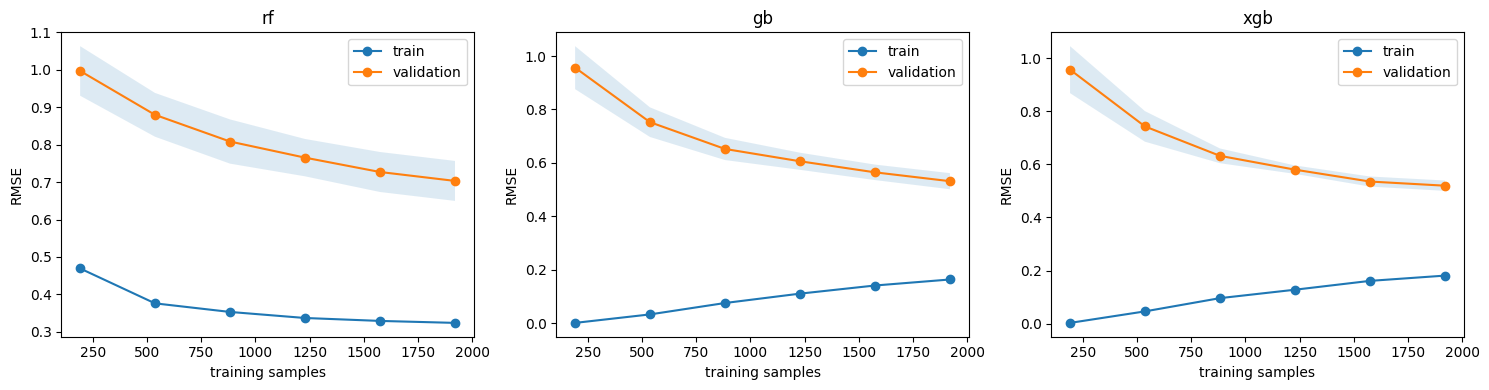

In [127]:
from sklearn.model_selection import learning_curve

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, (k, m) in zip(ax, ensemble_models.items()):
    sizes, tr_s, va_s = learning_curve(m, X_new_train, Y_train, cv=cv,
        train_sizes=np.linspace(0.1, 1.0, 6),
        scoring='neg_root_mean_squared_error', n_jobs=-1)
    a.plot(sizes, -tr_s.mean(1), 'o-', label='train')
    a.plot(sizes, -va_s.mean(1), 'o-', label='validation')
    a.fill_between(sizes, -va_s.mean(1)-va_s.std(1), -va_s.mean(1)+va_s.std(1), alpha=.15)
    a.set_title(k); a.set_xlabel('training samples'); a.set_ylabel('RMSE'); a.legend()
plt.tight_layout(); plt.show()

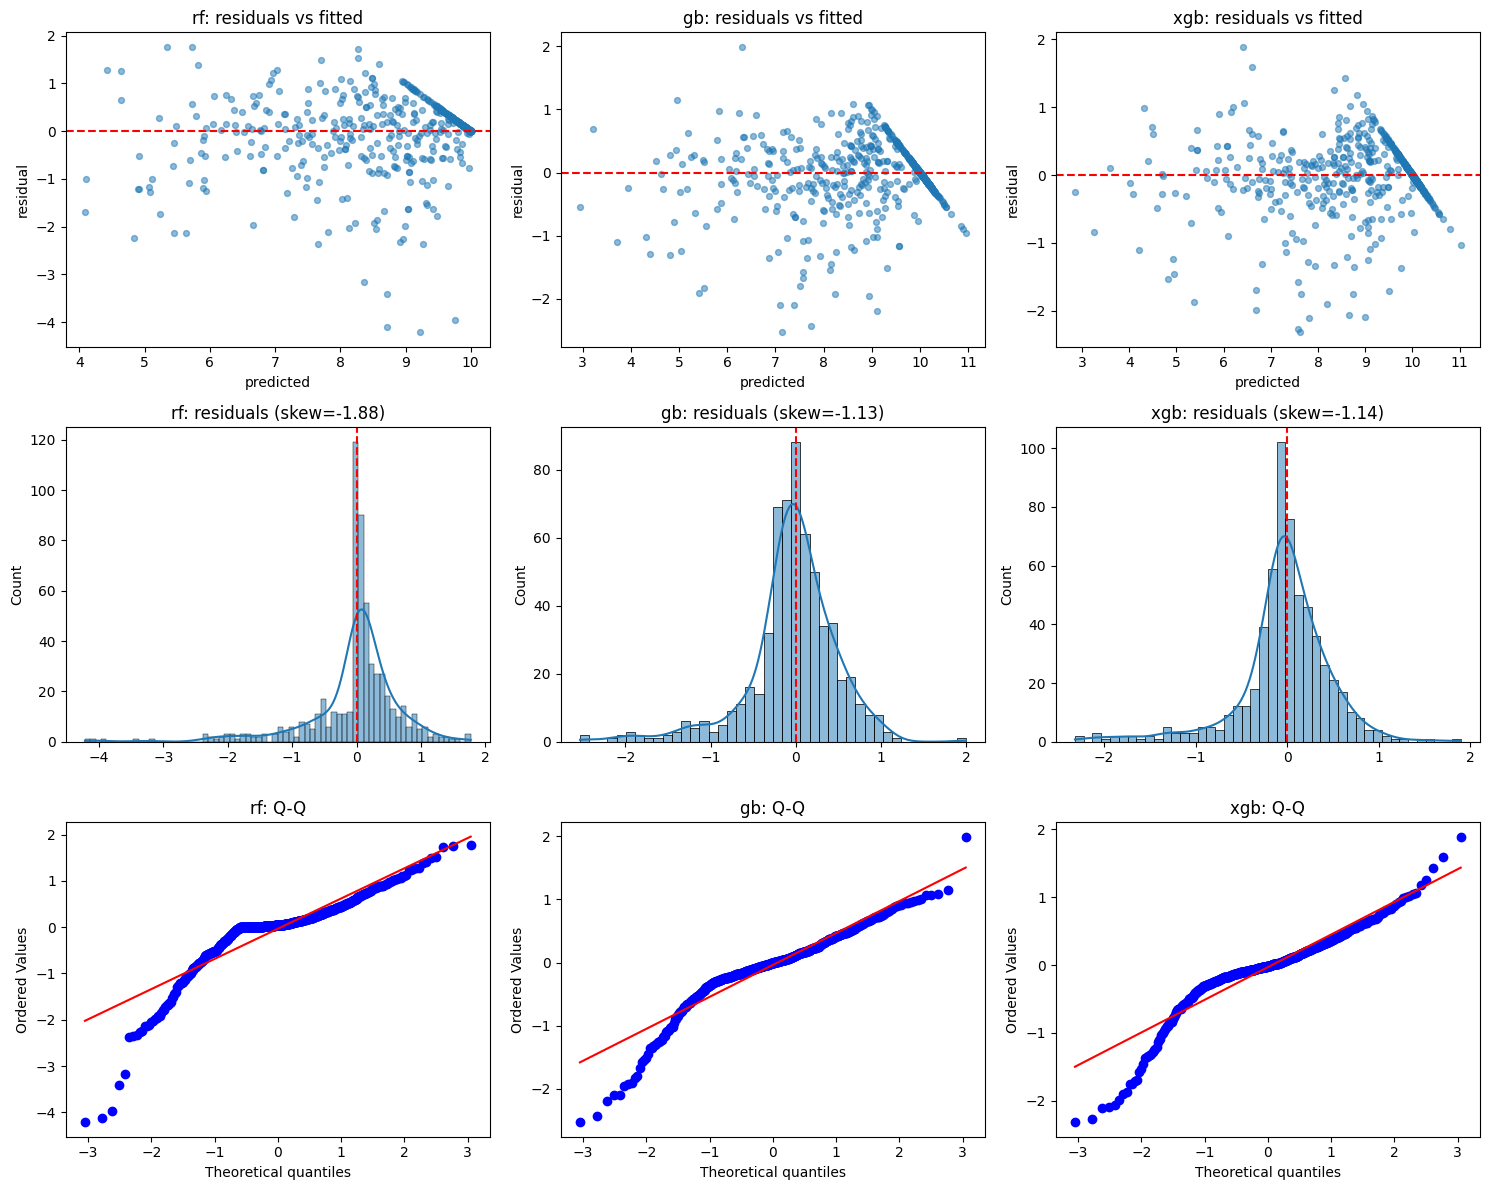

In [134]:
fig, ax = plt.subplots(3, 3, figsize=(15, 12))
for j, (k, m) in enumerate(ensemble_models.items()):
    pred = m.predict(X_new_test)
    r = np.asarray(Y_test) - pred
    ax[0, j].scatter(pred, r, alpha=.5, s=18); ax[0, j].axhline(0, color='r', ls='--')
    ax[0, j].set_title(f'{k}: residuals vs fitted')
    ax[0, j].set_xlabel('predicted'); ax[0, j].set_ylabel('residual')
    sns.histplot(r, kde=True, ax=ax[1, j]); ax[1, j].axvline(0, color='r', ls='--')
    ax[1, j].set_title(f'{k}: residuals (skew={st.skew(r):.2f})')
    st.probplot(r, dist='norm', plot=ax[2, j]); ax[2, j].set_title(f'{k}: Q-Q')
plt.tight_layout(); plt.show()

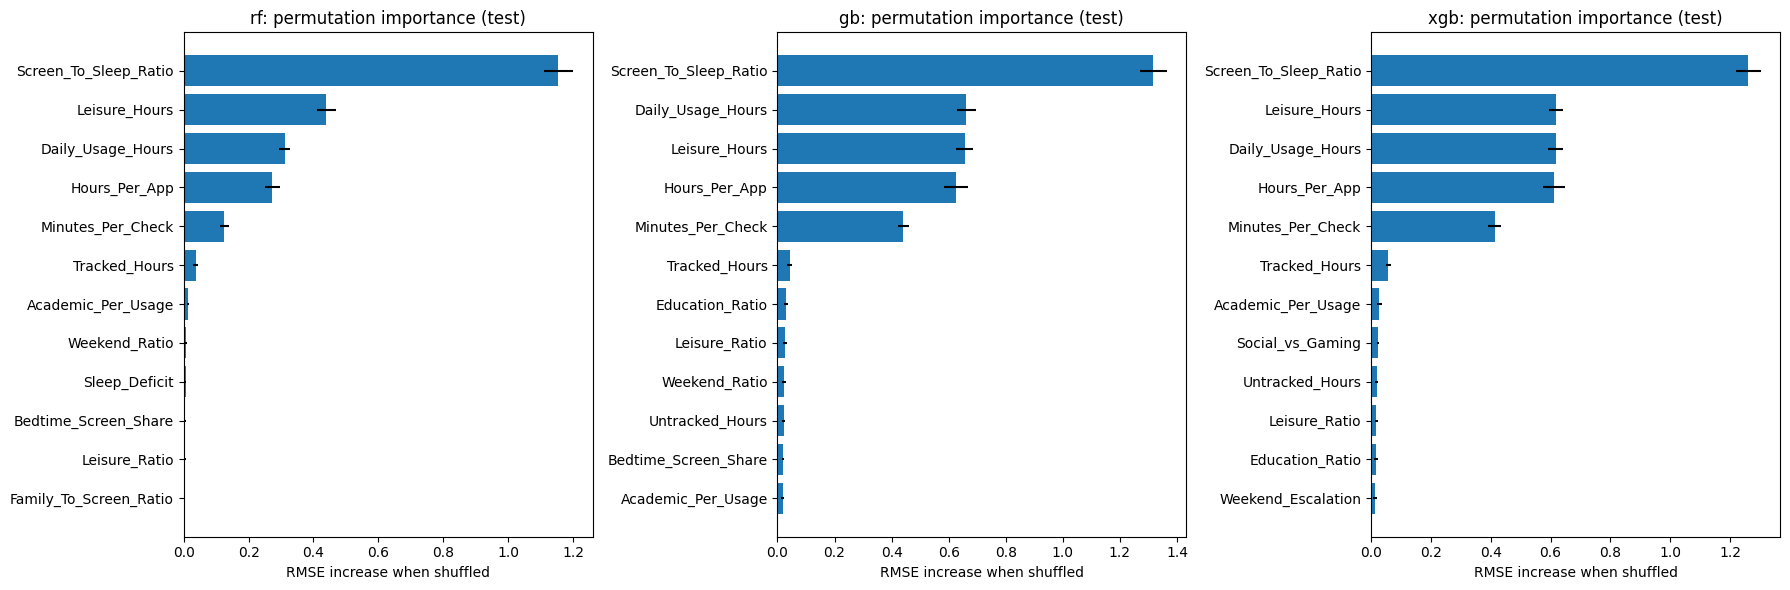

In [135]:
from sklearn.inspection import permutation_importance

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
for a, (k, m) in zip(ax, ensemble_models.items()):
    pi = permutation_importance(m, X_new_test, Y_test, n_repeats=20,
        random_state=42, n_jobs=-1, scoring='neg_root_mean_squared_error')
    order = pi.importances_mean.argsort()[-12:]
    a.barh([FEATURES[i] for i in order], pi.importances_mean[order],
           xerr=pi.importances_std[order])
    a.set_title(f'{k}: permutation importance (test)')
    a.set_xlabel('RMSE increase when shuffled')
plt.tight_layout(); plt.show()

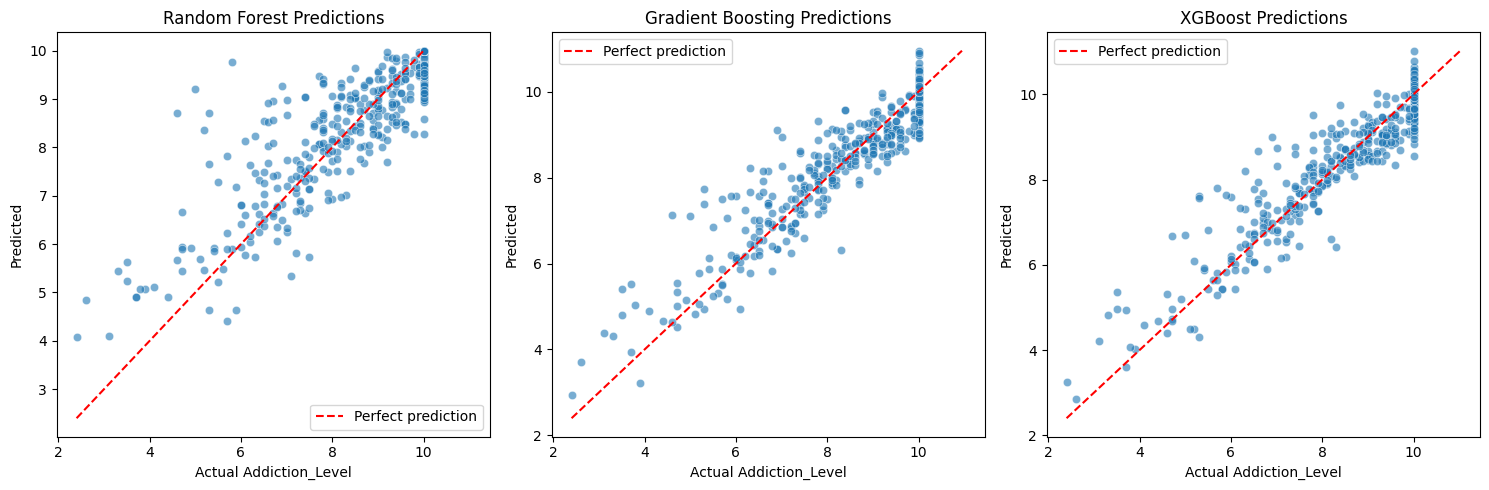

In [112]:
import numpy as np

fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharex=True)

preds = {
    'Random Forest': ensemble_models['rf'].predict(X_new_test),
    'Gradient Boosting': ensemble_models['gb'].predict(X_new_test),
    'XGBoost': ensemble_models['xgb'].predict(X_new_test),
}

for a, (name, y_pred) in zip(ax, preds.items()):
    sns.scatterplot(x=Y_test, y=y_pred, ax=a, alpha=0.6)
    lo = min(Y_test.min(), y_pred.min())
    hi = max(Y_test.max(), y_pred.max())
    a.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Perfect prediction')
    a.set_title(f'{name} Predictions')
    a.set_xlabel('Actual Addiction_Level')
    a.set_ylabel('Predicted')
    a.legend()

plt.tight_layout()
plt.show()

**Testing**

In [138]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# 1. The 18 features the model was trained on (must match selector output
#    order exactly, since S/StandardScaler was fit on this column order).
# ---------------------------------------------------------------------------
FEATURE_ORDER = [
    'Daily_Usage_Hours', 'Tracked_Hours', 'Untracked_Hours',
    'Leisure_Hours', 'Leisure_Ratio', 'Education_Ratio', 'Social_vs_Gaming',
    'Weekend_Escalation', 'Weekend_Ratio', 'Minutes_Per_Check',
    'Hours_Per_App', 'Sleep_Deficit', 'Screen_To_Sleep_Ratio',
    'Bedtime_Screen_Share', 'Online_To_Offline_Ratio',
    'Family_To_Screen_Ratio', 'Academic_Per_Usage', 'Unsupervised_Usage'
]

# ---------------------------------------------------------------------------
# 2. Severity bands for the 0-10 Addiction_Level output
# ---------------------------------------------------------------------------
def classify_addiction(score: float) -> str:
    if score < 4:
        return "Normal (1-3): minimal to no symptoms; behavior fully within normal ranges."
    elif score < 6:
        return "Moderate (4-5): mild to moderate impact; early signs of dependency or excess usage."
    elif score < 9:
        return "Addicted (6-8): significant impairment; clearly meets criteria for behavioral dependency."
    else:
        return "Severe Addicted (9-10): high severity; profound impairment across multiple areas of life."


# ---------------------------------------------------------------------------
# 3. Per-feature recommendation rules
#    NOTE: thresholds below are reasonable starting assumptions, not derived
#    from this dataset's actual distribution (the raw CSV wasn't available
#    when this cell was written). Adjust them against df.describe() /
#    df[FEATURE_ORDER].quantile([.25,.5,.75]) for your real data if the
#    advice feels too strict or too lenient.
# ---------------------------------------------------------------------------
def feature_recommendations(sample: dict) -> list[str]:
    tips = []

    if sample['Daily_Usage_Hours'] > 6:
        tips.append("Daily_Usage_Hours is high (>6h/day) - set a daily screen-time budget and use app timers.")

    if sample['Daily_Usage_Hours'] > 0 and (sample['Untracked_Hours'] / max(sample['Daily_Usage_Hours'], 1e-6)) > 0.4:
        tips.append("Untracked_Hours makes up a large share of usage - a lot of time is going unmonitored; enable screen-time tracking on all apps/devices.")

    if sample['Leisure_Ratio'] > 0.6:
        tips.append("Leisure_Ratio is high - most usage is recreational; try swapping some leisure sessions for offline hobbies.")

    if sample['Education_Ratio'] < 0.15:
        tips.append("Education_Ratio is low - very little usage goes toward learning; consider dedicating specific study/app-free blocks.")

    if sample['Weekend_Escalation'] > 1.3:
        tips.append("Weekend_Escalation is high - usage spikes sharply on weekends; plan offline weekend activities in advance.")

    if sample['Weekend_Ratio'] > 0.6:
        tips.append("Weekend_Ratio is high - weekends are dominated by screen time; introduce a weekend 'no-phone' window.")

    if sample['Minutes_Per_Check'] < 5:
        tips.append("Minutes_Per_Check is very low - the phone is checked very frequently; try turning off non-essential notifications.")

    if sample['Hours_Per_App'] < 0.5:
        tips.append("Hours_Per_App is low - time is spread thin across many apps (compulsive switching); consider decluttering/removing rarely-needed apps.")

    if sample['Sleep_Deficit'] > 2:
        tips.append("Sleep_Deficit is high - sleep is being significantly cut into; set a hard device curfew before bedtime.")

    if sample['Screen_To_Sleep_Ratio'] > 1:
        tips.append("Screen_To_Sleep_Ratio is high - more time on screen than asleep; prioritize sleep hygiene and reduce late-night usage.")

    if sample['Bedtime_Screen_Share'] > 0.3:
        tips.append("Bedtime_Screen_Share is high - a large chunk of usage happens right before bed; charge the phone outside the bedroom.")

    if sample['Online_To_Offline_Ratio'] > 2:
        tips.append("Online_To_Offline_Ratio is high - online activity dominates offline activity; schedule regular offline/in-person activities.")

    if sample['Family_To_Screen_Ratio'] < 0.2:
        tips.append("Family_To_Screen_Ratio is low - little time is spent with family relative to screens; build in device-free family time.")

    if sample['Academic_Per_Usage'] < 0.2:
        tips.append("Academic_Per_Usage is low - usage isn't translating into academic benefit; review whether usage is displacing schoolwork.")

    if sample['Unsupervised_Usage'] > 0.7:
        tips.append("Unsupervised_Usage is high - most usage happens without supervision; consider more shared/monitored usage, especially for younger users.")

    if not tips:
        tips.append("No red-flag thresholds triggered - usage pattern looks generally healthy across the tracked features.")

    return tips


# ---------------------------------------------------------------------------
# 4. Main test/evaluation function
# ---------------------------------------------------------------------------
def evaluate_sample(sample: dict, models=None, scaler=None):
    """
    sample : dict with all 18 keys in FEATURE_ORDER
    models : dict of fitted regressors (defaults to `ensemble_models` in memory)
    scaler : fitted StandardScaler (defaults to `S` in memory)
    """
    models = models if models is not None else ensemble_models
    scaler = scaler if scaler is not None else S

    missing = [f for f in FEATURE_ORDER if f not in sample]
    if missing:
        raise ValueError(f"Missing features in sample: {missing}")

    row = pd.DataFrame([{f: sample[f] for f in FEATURE_ORDER}])
    row_scaled = scaler.transform(row)

    preds = {name: float(model.predict(row_scaled)[0]) for name, model in models.items()}
    avg_pred = float(np.mean(list(preds.values())))
    avg_pred = np.clip(avg_pred, 0, 10)

    print("Per-model predicted Addiction_Level:")
    for name, val in preds.items():
        print(f"  {name:>4}: {val:.2f}")
    print(f"\nEnsemble average Addiction_Level: {avg_pred:.2f} / 10")
    print(f"Category: {classify_addiction(avg_pred)}")

    print("\nRecommendations based on input features:")
    for tip in feature_recommendations(sample):
        print(f"  - {tip}")

    return {"predictions": preds, "average": avg_pred, "category": classify_addiction(avg_pred)}


# ---------------------------------------------------------------------------
# 5. Example usage - replace these values with real feature values to test
# ---------------------------------------------------------------------------
test_sample = {
    'Daily_Usage_Hours': 7.5,
    'Tracked_Hours': 5.0,
    'Untracked_Hours': 2.5,
    'Leisure_Hours': 5.8,
    'Leisure_Ratio': 0.77,
    'Education_Ratio': 0.08,
    'Social_vs_Gaming': 1.4,
    'Weekend_Escalation': 1.5,
    'Weekend_Ratio': 0.68,
    'Minutes_Per_Check': 3.2,
    'Hours_Per_App': 0.35,
    'Sleep_Deficit': 2.8,
    'Screen_To_Sleep_Ratio': 1.2,
    'Bedtime_Screen_Share': 0.42,
    'Online_To_Offline_Ratio': 2.6,
    'Family_To_Screen_Ratio': 0.12,
    'Academic_Per_Usage': 0.15,
    'Unsupervised_Usage': 0.81,
}

result = evaluate_sample(test_sample)
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ---------------------------------------------------------------------------
# 1. Structured feature rules (feature, direction, threshold, tip)
#    direction 'high' -> flagged when value > threshold
#    direction 'low'  -> flagged when value < threshold
#    'ratio' -> special case for Untracked_Hours (computed vs Daily_Usage_Hours)
# ---------------------------------------------------------------------------
FEATURE_RULES = [
    ('Daily_Usage_Hours',       'high', 6,    "High daily usage - set a screen-time budget and app timers."),
    ('Leisure_Ratio',           'high', 0.6,  "Mostly recreational usage - swap some leisure time for offline hobbies."),
    ('Education_Ratio',         'low',  0.15, "Very little usage goes toward learning - add dedicated study blocks."),
    ('Weekend_Escalation',      'high', 1.3,  "Usage spikes sharply on weekends - plan offline weekend activities."),
    ('Weekend_Ratio',           'high', 0.6,  "Weekends dominated by screen time - introduce a weekend no-phone window."),
    ('Minutes_Per_Check',       'low',  5,    "Phone checked very frequently - turn off non-essential notifications."),
    ('Hours_Per_App',           'low',  0.5,  "Time spread thin across many apps - declutter rarely-used apps."),
    ('Sleep_Deficit',           'high', 2,    "Sleep is being cut into - set a hard device curfew before bed."),
    ('Screen_To_Sleep_Ratio',   'high', 1,    "More time on screen than asleep - prioritize sleep hygiene."),
    ('Bedtime_Screen_Share',    'high', 0.3,  "Large chunk of usage right before bed - charge phone outside bedroom."),
    ('Online_To_Offline_Ratio','high', 2,    "Online activity dominates offline - schedule offline/in-person time."),
    ('Family_To_Screen_Ratio', 'low',  0.2,  "Little time with family relative to screens - build device-free family time."),
    ('Academic_Per_Usage',      'low',  0.2,  "Usage isn't translating into academic benefit - review study displacement."),
    ('Unsupervised_Usage',      'high', 0.7,  "Most usage happens without supervision - encourage more shared usage."),
]

CATEGORY_COLORS = {
    "Normal": "#2ecc71",
    "Moderate": "#f1c40f",
    "Addicted": "#e67e22",
    "Severe Addicted": "#e74c3c",
}

def category_key(score: float) -> str:
    if score < 4:
        return "Normal"
    elif score < 6:
        return "Moderate"
    elif score < 9:
        return "Addicted"
    else:
        return "Severe Addicted"


def build_flags(sample: dict):
    flags = []
    for feat, direction, thresh, tip in FEATURE_RULES:
        val = sample[feat]
        flagged = (val > thresh) if direction == 'high' else (val < thresh)
        # normalized deviation, just for bar length / color intensity
        deviation = (val - thresh) / thresh if thresh != 0 else val
        flags.append({
            'feature': feat, 'value': val, 'threshold': thresh,
            'direction': direction, 'flagged': flagged,
            'deviation': deviation, 'tip': tip
        })
    return flags


def visualize_result(sample: dict, result: dict):
    score = result['average']
    cat_key = category_key(score)
    color = CATEGORY_COLORS[cat_key]

    # --- Gauge chart -------------------------------------------------------
    gauge = go.Figure(go.Indicator(
        mode="gauge+number+delta",
        value=score,
        number={'suffix': " / 10", 'font': {'size': 40}},
        delta={'reference': 5, 'increasing': {'color': "#e74c3c"}, 'decreasing': {'color': "#2ecc71"}},
        title={'text': f"Predicted Addiction_Level<br><span style='font-size:0.8em;color:{color}'>{cat_key}</span>"},
        gauge={
            'axis': {'range': [0, 10], 'tickwidth': 1},
            'bar': {'color': color, 'thickness': 0.3},
            'steps': [
                {'range': [0, 4], 'color': '#eafaf1'},
                {'range': [4, 6], 'color': '#fef9e7'},
                {'range': [6, 9], 'color': '#fdf0e2'},
                {'range': [9, 10], 'color': '#fdecea'},
            ],
            'threshold': {
                'line': {'color': "black", 'width': 3},
                'thickness': 0.9,
                'value': score
            }
        }
    ))
    gauge.update_layout(height=380, margin=dict(t=80, b=10, l=30, r=30))
    gauge.show()

    # --- Per-model prediction mini bar chart --------------------------------
    model_fig = go.Figure(go.Bar(
        x=list(result['predictions'].keys()),
        y=list(result['predictions'].values()),
        marker_color=[CATEGORY_COLORS[category_key(v)] for v in result['predictions'].values()],
        text=[f"{v:.2f}" for v in result['predictions'].values()],
        textposition='outside'
    ))
    model_fig.update_layout(
        title="Predicted Addiction_Level by model",
        yaxis=dict(title="Addiction_Level", range=[0, 10]),
        height=350, margin=dict(t=60, b=30, l=30, r=30)
    )
    model_fig.show()

    # --- Feature flags horizontal bar (interactive, hover = recommendation) -
    flags = build_flags(sample)
    flags_sorted = sorted(flags, key=lambda d: d['deviation'], reverse=True)

    feat_fig = go.Figure(go.Bar(
        x=[f['deviation'] for f in flags_sorted],
        y=[f['feature'] for f in flags_sorted],
        orientation='h',
        marker_color=['#e74c3c' if f['flagged'] else '#2ecc71' for f in flags_sorted],
        customdata=[[f['value'], f['threshold'], f['tip']] for f in flags_sorted],
        hovertemplate=(
            "<b>%{y}</b><br>"
            "value: %{customdata[0]:.2f}<br>"
            "threshold: %{customdata[1]:.2f}<br>"
            "%{customdata[2]}<extra></extra>"
        )
    ))
    feat_fig.update_layout(
        title="Feature flags vs. threshold (red = flagged, hover for recommendation)",
        xaxis=dict(title="Relative deviation from threshold"),
        height=550, margin=dict(t=60, b=30, l=150, r=30)
    )
    feat_fig.add_vline(x=0, line_width=1, line_dash="dash", line_color="grey")
    feat_fig.show()

    n_flagged = sum(f['flagged'] for f in flags)
    print(f"{n_flagged} of {len(flags)} tracked features are flagged.")


visualize_result(test_sample, result)



Per-model predicted Addiction_Level:
    rf: 9.78
    gb: 9.65
   xgb: 9.72

Ensemble average Addiction_Level: 9.72 / 10
Category: Severe Addicted (9-10): high severity; profound impairment across multiple areas of life.

Recommendations based on input features:
  - Daily_Usage_Hours is high (>6h/day) - set a daily screen-time budget and use app timers.
  - Leisure_Ratio is high - most usage is recreational; try swapping some leisure sessions for offline hobbies.
  - Education_Ratio is low - very little usage goes toward learning; consider dedicating specific study/app-free blocks.
  - Weekend_Escalation is high - usage spikes sharply on weekends; plan offline weekend activities in advance.
  - Weekend_Ratio is high - weekends are dominated by screen time; introduce a weekend 'no-phone' window.
  - Minutes_Per_Check is very low - the phone is checked very frequently; try turning off non-essential notifications.
  - Hours_Per_App is low - time is spread thin across many apps (compulsive

14 of 14 tracked features are flagged.


In [113]:
# import joblib
# from pathlib import Path

# MODELS_DIR = Path('../models')
# MODELS_DIR.mkdir(exist_ok=True)

# # The estimators expect the 18 selected features, standard-scaled - not the raw
# # frame - so the fitted selector and scaler have to travel with them.
# joblib.dump(
#     {'selector': selector, 'scaler': S, 'features': list(X_new.columns)},
#     MODELS_DIR / 'preprocessing.pkl',
# )
# print(f"Saved: preprocessing.pkl  (selector + scaler, {len(X_new.columns)} features)")

# for name, model in ensemble_models.items():
#     path = MODELS_DIR / f'model_{name}.pkl'
#     joblib.dump(model, path)
#     print(f"Saved: {path.name}  ({type(model).__name__})")
